<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/091_lr_schedules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 091 — Learning Rate Scheduling

**Phase 6: Deep Learning & PyTorch**

## 📌 Topics
- Step decay and exponential decay
- Cosine Annealing and OneCycleLR policies
- Learning Rate Finder algorithm


Epoch 0: LR = 0.10000
Epoch 9: LR = 0.10000
Epoch 10: LR = 0.05000
Epoch 19: LR = 0.05000
Epoch 20: LR = 0.02500
Epoch 29: LR = 0.02500


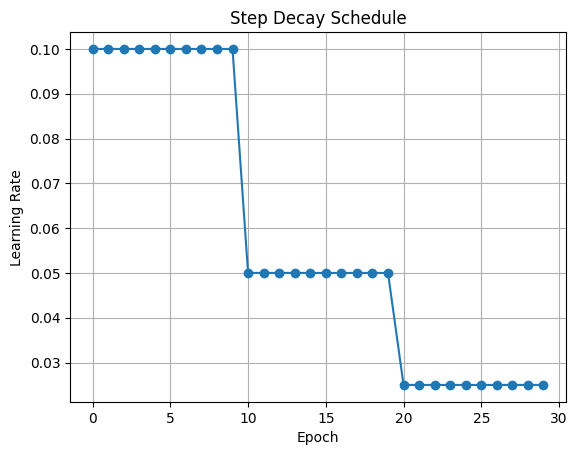

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def step_decay(epoch, lr0=0.1, gamma=0.5, step_size=10):
    return lr0 * (gamma ** (epoch // step_size))

epochs = np.arange(0, 30)
lrs = [step_decay(e) for e in epochs]

for e in [0, 9, 10, 19, 20, 29]:
    print(f"Epoch {e}: LR = {step_decay(e):.5f}")

plt.plot(epochs, lrs, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Step Decay Schedule")
plt.grid(True)
plt.show()

Epoch 0: LR = 0.10000
Epoch 10: LR = 0.03679
Epoch 20: LR = 0.01353
Epoch 30: LR = 0.00498


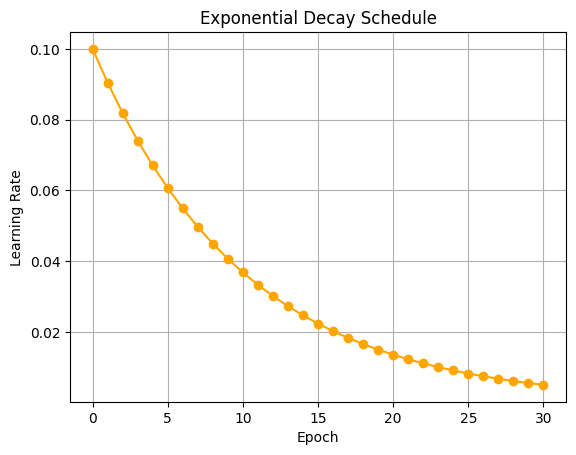

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def exponential_decay(epoch, lr0=0.1, k=0.1):
    return lr0 * np.exp(-k * epoch)

epochs = np.arange(0, 31)
lrs = [exponential_decay(e) for e in epochs]

for e in [0, 10, 20, 30]:
    print(f"Epoch {e}: LR = {exponential_decay(e):.5f}")

plt.plot(epochs, lrs, marker='o', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Exponential Decay Schedule")
plt.grid(True)
plt.show()

Epoch 0: LR = 0.10000
Epoch 15: LR = 0.05000
Epoch 30: LR = 0.00000


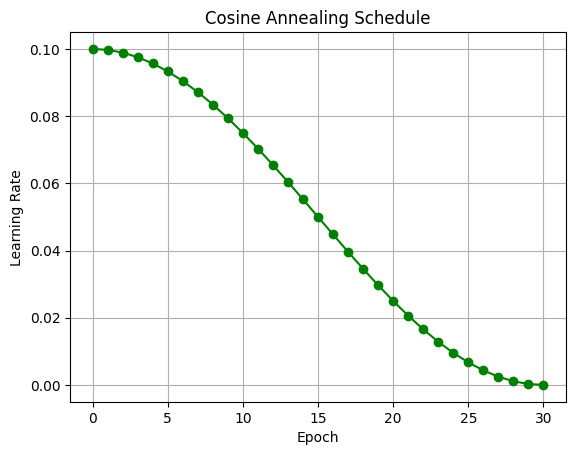

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_annealing(epoch, lr_max=0.1, lr_min=0.0, T=30):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / T))

epochs = np.arange(0, 31)
lrs = [cosine_annealing(e) for e in epochs]

for e in [0, 15, 30]:
    print(f"Epoch {e}: LR = {cosine_annealing(e):.5f}")

plt.plot(epochs, lrs, marker='o', color='green')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Schedule")
plt.grid(True)
plt.show()

Epoch 0: LR = 0.00100
Epoch 9: LR = 0.10000
Epoch 20: LR = 0.04680
Epoch 30: LR = 0.00100


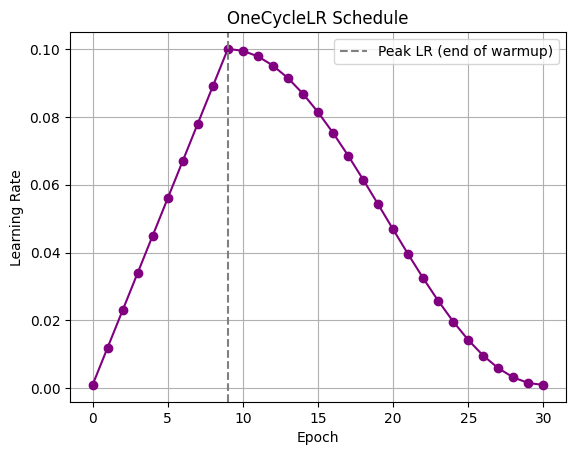

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def one_cycle_lr(epoch, T=30, lr_min=0.001, lr_max=0.1, pct=0.3):
    warmup_epochs = pct * T
    if epoch <= warmup_epochs:
        # Phase 1: linear warmup
        return lr_min + (lr_max - lr_min) * (epoch / warmup_epochs)
    else:
        # Phase 2: cosine anneal down
        progress = (epoch - warmup_epochs) / (T - warmup_epochs)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

epochs = np.arange(0, 31)
lrs = [one_cycle_lr(e) for e in epochs]

for e in [0, 9, 20, 30]:
    print(f"Epoch {e}: LR = {one_cycle_lr(e):.5f}")

plt.plot(epochs, lrs, marker='o', color='purple')
plt.axvline(x=9, linestyle='--', color='gray', label='Peak LR (end of warmup)')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("OneCycleLR Schedule")
plt.legend()
plt.grid(True)
plt.show()

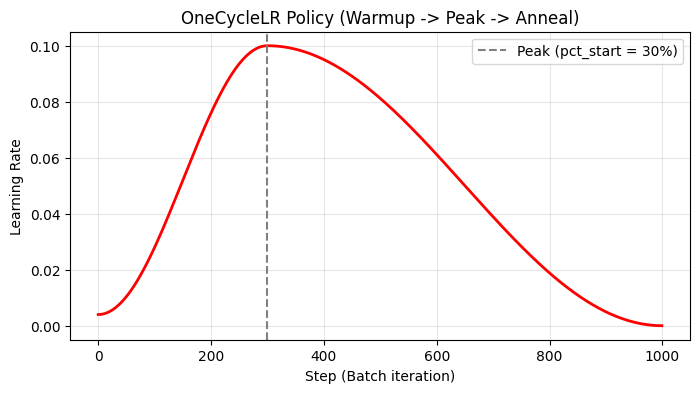

In [6]:
def one_cycle_lr(step, total_steps=1000, lr_max=0.1, pct_start=0.3, div_factor=25.0, final_div_factor=10000.0):
    lr_initial = lr_max / div_factor
    lr_final = lr_max / final_div_factor
    step_size_up = int(total_steps * pct_start)
    step_size_down = total_steps - step_size_up

    if step <= step_size_up:
        # Phase 1: Cosine warmup
        pct = step / step_size_up
        return lr_initial + 0.5 * (lr_max - lr_initial) * (1 - np.cos(np.pi * pct))
    else:
        # Phase 2: Cosine cooldown
        pct = (step - step_size_up) / step_size_down
        return lr_final + 0.5 * (lr_max - lr_final) * (1 + np.cos(np.pi * pct))

steps = np.arange(0, 1000)
lrs_onecycle = [one_cycle_lr(s) for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs_onecycle, color='red', linewidth=2)
plt.axvline(x=300, color='gray', linestyle='--', label='Peak (pct_start = 30%)')
plt.xlabel("Step (Batch iteration)")
plt.ylabel("Learning Rate")
plt.title("OneCycleLR Policy (Warmup -> Peak -> Anneal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Suggested optimal LR ≈ 0.04169


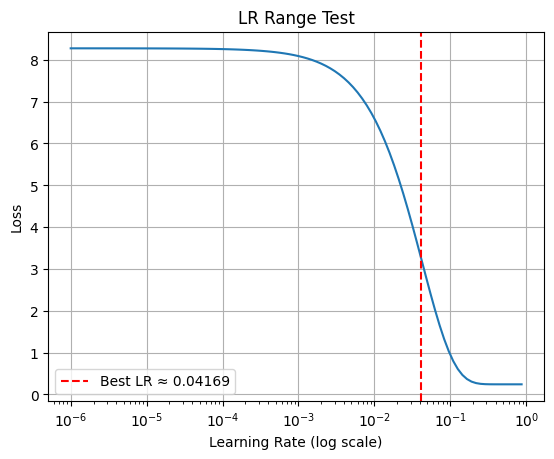

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Toy dataset (y = 3x + noise) ---
np.random.seed(42)
X = np.random.randn(200, 1)
y = 3 * X.flatten() + np.random.randn(200) * 0.5

# --- LR Range Test ---
N = 100                      # total test iterations
lr_start, lr_end = 1e-6, 1.0
lrs = [lr_start * (lr_end/lr_start)**(i/N) for i in range(N)]

w, b = 0.0, 0.0              # weight, bias init
losses = []

for i, lr in enumerate(lrs):
    y_pred = w * X.flatten() + b
    loss = np.mean((y - y_pred)**2)     # MSE (Day 1 wala)
    losses.append(loss)

    # gradients (Day 2 wala gradient descent rule)
    dw = -2 * np.mean(X.flatten() * (y - y_pred))
    db = -2 * np.mean(y - y_pred)

    # update rule with test LR
    w -= lr * dw
    b -= lr * db

    # divergence safety stop
    if loss > 100 or np.isnan(loss):
        print(f"Diverged at iteration {i}, LR = {lr:.5f}")
        break

# --- Find best LR: steepest loss drop ---
losses = np.array(losses)
gradients_of_loss = np.diff(losses)
best_idx = np.argmin(gradients_of_loss)   # steepest descent point
best_lr = lrs[best_idx]

print(f"Suggested optimal LR ≈ {best_lr:.5f}")

plt.plot(lrs[:len(losses)], losses)
plt.xscale('log')
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss")
plt.title("LR Range Test")
plt.axvline(x=best_lr, linestyle='--', color='red', label=f'Best LR ≈ {best_lr:.5f}')
plt.legend()
plt.grid(True)
plt.show()